# Homework 1: Deep Neural Networks for Robot Push Prediction

This notebook trains three models on data collected from a MuJoCo simulation of a UR5e robot arm pushing objects on a tabletop. The simulation acts as a physics oracle — we collect ground-truth (image, action, outcome) pairs from it, then train neural networks to predict outcomes without running the simulation.

**Three deliverables:**
1. **MLP** — predicts final (x, y) object position from a flattened image + action
2. **CNN** — same prediction but with convolutional spatial awareness
3. **CNN Encoder-Decoder** — predicts the entire post-push scene image

## Setup
Import dependencies and select the compute device. MPS is Apple Silicon GPU acceleration; falls back to CPU if unavailable.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


## Data Loading

The simulation was run 1000 times (4 parallel processes × 250 episodes). Each episode:
1. Resets with a random object (cube or sphere, random size 2–3 cm) at a fixed table position
2. Captures a top-down 128×128 RGB image **before** the push (`img_before`)
3. Executes one of 4 push actions (right, left, forward, backward)
4. Captures the image and object (x, y) position **after** the push

Data is stored in sharded `.pt` files in `src/data/`. We merge the 4 shards here and preprocess:
- **Images** are normalised from uint8 [0, 255] → float32 [0, 1]
- **Actions** are one-hot encoded: action 2 → `[0, 0, 1, 0]`

In [2]:
imgs_before = torch.cat([torch.load(f"data/imgs_before_{i}.pt", weights_only=False) for i in range(4)])
imgs_after  = torch.cat([torch.load(f"data/imgs_after_{i}.pt",  weights_only=False) for i in range(4)])
positions   = torch.cat([torch.load(f"data/positions_{i}.pt",   weights_only=False) for i in range(4)])
actions_raw = torch.cat([torch.load(f"data/actions_{i}.pt",     weights_only=False) for i in range(4)])

# Normalize images and one-hot encode actions
imgs_before_f = imgs_before.float() / 255.0
imgs_after_f  = imgs_after.float()  / 255.0
actions_oh    = F.one_hot(actions_raw.long(), num_classes=4).float()

print("imgs_before_f:", imgs_before_f.shape, imgs_before_f.min().item(), imgs_before_f.max().item())
print("positions:", positions.shape, positions.min().item(), positions.max().item())
print("actions_oh:", actions_oh.shape)

imgs_before_f: torch.Size([1000, 3, 128, 128]) 0.007843137718737125 1.0
positions: torch.Size([1000, 2]) -0.4158131182193756 1.1349055767059326
actions_oh: torch.Size([1000, 4])


## Dataset and DataLoaders

`PushDataset` wraps all four tensors into a standard PyTorch `Dataset`. Each item returns `(img_before, img_after, position, action_one_hot)`.

We use an 80/20 train/validation split (800/200 samples) with a fixed random seed for reproducibility. Both loaders use batch size 64.

In [3]:
class PushDataset(Dataset):
    def __init__(self, imgs_before, imgs_after, positions, actions_oh):
        self.imgs_before = imgs_before
        self.imgs_after  = imgs_after
        self.positions   = positions
        self.actions_oh  = actions_oh

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, idx):
        return (self.imgs_before[idx], self.imgs_after[idx],
                self.positions[idx], self.actions_oh[idx])

dataset = PushDataset(imgs_before_f, imgs_after_f, positions, actions_oh)
n_train = int(0.8 * len(dataset))
n_val   = len(dataset) - n_train
train_set, val_set = random_split(dataset, [n_train, n_val],
                                  generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False)
print(f"Train: {n_train}  Val: {n_val}")

Train: 800  Val: 200


## Sanity Check: Visualise Samples

Before training, verify the data looks correct. Each column shows one episode:
- **Top row**: the scene before the push, with the action label
- **Bottom row**: the scene after the push, with the final object position

The object (red cube or sphere) should visibly shift between rows, and the direction of movement should match the action (0=right, 1=left, 2=forward, 3=backward).

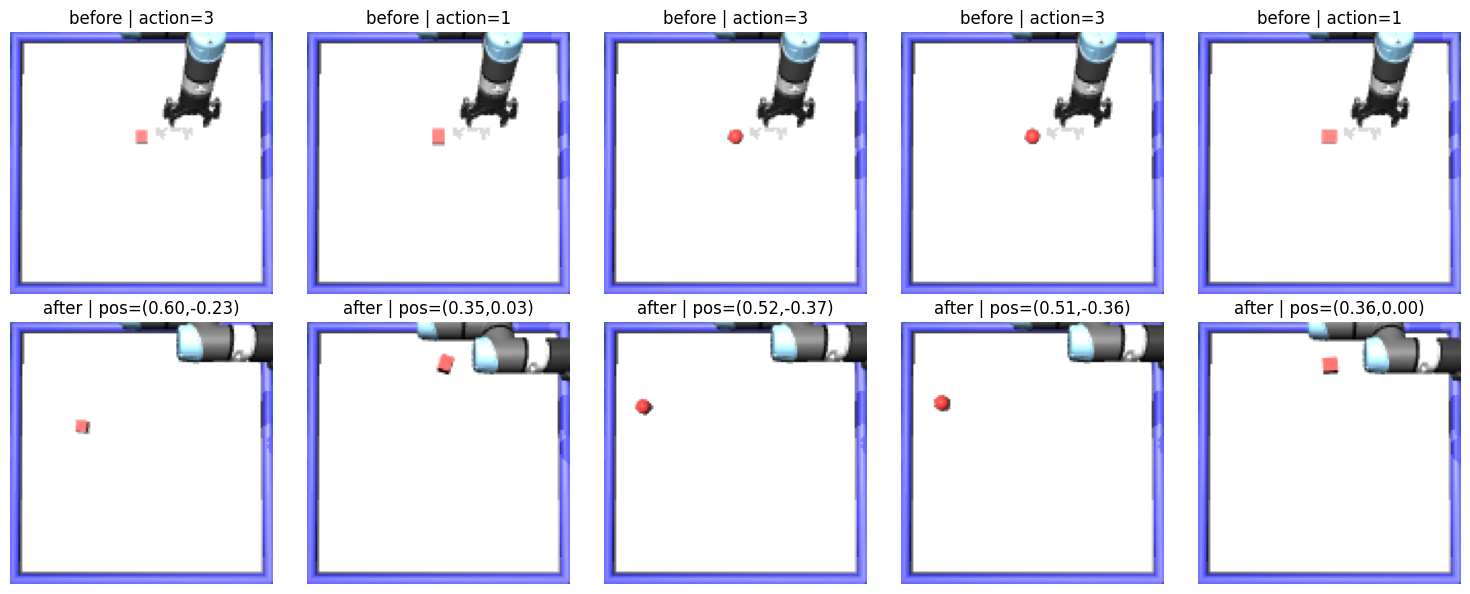

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    axes[0, i].imshow(imgs_before[i].permute(1, 2, 0))
    axes[0, i].set_title(f"before | action={actions_raw[i].item()}")
    axes[1, i].imshow(imgs_after[i].permute(1, 2, 0))
    axes[1, i].set_title(f"after | pos=({positions[i,0]:.2f},{positions[i,1]:.2f})")
    for ax in axes[:, i]:
        ax.axis("off")
plt.tight_layout()
plt.show()